## DnCNN Image Denoising Inference - Noise Level Comparison

This notebook implements image denoising using a pretrained DnCNN color model on RGB images.

### Import dependencies

In [20]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Verify dataset paths

In [22]:
import os
print("Clean count:", len(os.listdir("../data/clean")))
print("Degraded σ=50 count:", len(os.listdir("../data/degraded_sigma_50")))
print("Degraded σ=25 count:", len(os.listdir("../data/degraded_sigma_25")))
print("Degraded σ=15 count:", len(os.listdir("../data/degraded_sigma_15")))

Clean count: 50
Degraded σ=50 count: 50
Degraded σ=25 count: 50
Degraded σ=15 count: 50


### Define DnCNN model architecture

In [23]:
class DnCNN(nn.Module):
    def __init__(self, channels=3, num_of_layers=17, features=64):
        super(DnCNN, self).__init__()

        layers = []
        layers.append(nn.Conv2d(channels, features, 3, padding=1, bias=False))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(num_of_layers - 2):
            layers.append(nn.Conv2d(features, features, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(features))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(features, channels, 3, padding=1, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.dncnn(x)
        return x - noise

### Initialize color DnCNN model

In [24]:
model = DnCNN(channels=3, num_of_layers=17)
model.eval()

print("Color DnCNN model initialized")

Color DnCNN model initialized


### Load pretrained weights

- Pretrained weights source: [cszn/KAIR](https://github.com/cszn/KAIR/tree/master/model_zoo)
- To download the pretrained weights, create a `/model/weights` directory and run this command in the terminal: `wget -O model/weights/dncnn_25.pth https://github.com/cszn/KAIR/raw/master/model_zoo/dncnn_25.pth`

In [25]:
weights_path = "../model/weights/dncnn_color_blind.pth"

state_dict = torch.load(weights_path, map_location="cpu")

if "params" in state_dict:
    state_dict = state_dict["params"]

model.load_state_dict(state_dict, strict=False)
model.eval()

print("Weights are loaded successfully.")

Weights are loaded successfully.


### Sigma = 50

In [26]:
sigma = 50
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

os.makedirs(enhanced_dir, exist_ok=True)

filename = sorted(os.listdir(degraded_dir))[0]

degraded_path = os.path.join(degraded_dir, filename)
clean_path = os.path.join("../data/clean", filename)

print("Testing:", filename)
print("Using degraded folder:", degraded_dir)
print("Enhanced output folder:", enhanced_dir)

Testing: image_0.png
Using degraded folder: ../data/degraded_sigma_50
Enhanced output folder: ../data/enhanced_sigma_50


#### Load RGB images

In [27]:
degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)

degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

print("Degraded shape:", degraded.shape)
print("Clean shape:", clean.shape)

Degraded shape: (1356, 2040, 3)
Clean shape: (1356, 2040, 3)


#### Visualize degraded image

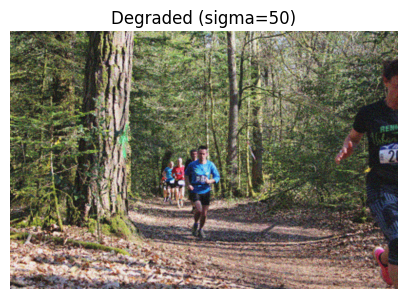

In [28]:
plt.figure(figsize=(5,5))
plt.title(f"Degraded (sigma={sigma})")
plt.imshow(degraded)
plt.axis("off")
plt.show()

#### Preprocess image for model

In [29]:
img = degraded.astype(np.float32) / 255.0 # H,W,3
img = np.transpose(img, (2, 0, 1))        # 3,H,W
img = np.expand_dims(img, axis=0)         # 1,3,H,W

input_tensor = torch.from_numpy(img).float()

print("Tensor shape:", input_tensor.shape)

Tensor shape: torch.Size([1, 3, 1356, 2040])


#### Run denoising inference

In [30]:
with torch.no_grad():
    output = model(input_tensor)

print("Inference completed.")

Inference completed.


#### Post process output image

In [31]:
out = output.squeeze(0).cpu().numpy()
out = np.transpose(out, (1, 2, 0))
out = np.clip(out, 0, 1)
out = (out * 255).astype(np.uint8)

print("Output shape:", out.shape)

# Save this single test output
save_path = os.path.join(enhanced_dir, filename)
out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, out_bgr)

print("Saved test output to:", save_path)

Output shape: (1356, 2040, 3)
Saved test output to: ../data/enhanced_sigma_50/image_0.png


#### Compare results

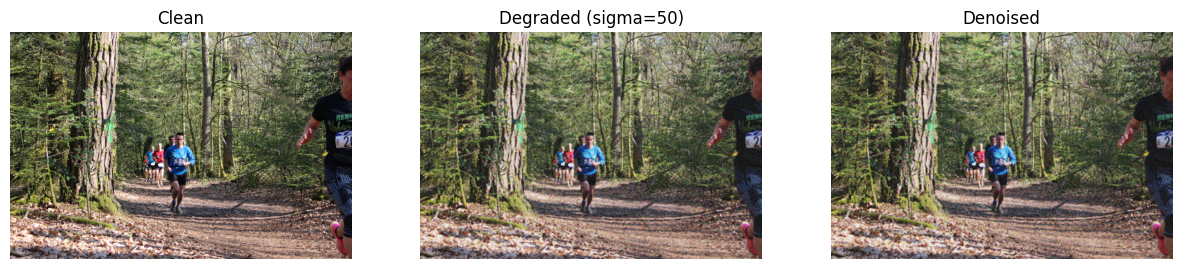

In [33]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Clean")
plt.imshow(clean)
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Degraded (sigma={sigma})")
plt.imshow(degraded)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Denoised")
plt.imshow(out)
plt.axis("off")

plt.show()

#### Save outputs for all images

In [34]:
# Save denoised outputs for all images in the selected sigma folder
file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    degraded_path = os.path.join(degraded_dir, filename)

    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    if degraded is None:
        print(f"Skipping {filename}: could not read image")
        continue

    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

    img = degraded.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    input_tensor = torch.from_numpy(img).float()

    with torch.no_grad():
        output = model(input_tensor)

    out = output.squeeze(0).cpu().numpy()
    out = np.transpose(out, (1, 2, 0))
    out = np.clip(out, 0, 1)
    out = (out * 255).astype(np.uint8)

    save_path = os.path.join(enhanced_dir, filename)
    out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, out_bgr)

print(f"Done. Saved all denoised images to {enhanced_dir}")

Done. Saved all denoised images to ../data/enhanced_sigma_50


In [35]:
# Evaluate sigma=50 results and display comparison table
import os
import cv2
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

sigma = 50
clean_dir = "../data/clean"
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

results = []

file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    clean_path = os.path.join(clean_dir, filename)
    degraded_path = os.path.join(degraded_dir, filename)
    enhanced_path = os.path.join(enhanced_dir, filename)

    clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)
    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    enhanced = cv2.imread(enhanced_path, cv2.IMREAD_COLOR)

    if clean is None or degraded is None or enhanced is None:
        print(f"Skipping {filename}: missing file")
        continue

    clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)
    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    psnr_degraded = compare_psnr(clean, degraded, data_range=255)
    psnr_denoised = compare_psnr(clean, enhanced, data_range=255)

    ssim_degraded = compare_ssim(clean, degraded, channel_axis=2, data_range=255)
    ssim_denoised = compare_ssim(clean, enhanced, channel_axis=2, data_range=255)

    results.append({
        "image": filename,
        "PSNR_degraded": round(psnr_degraded, 2),
        "PSNR_denoised": round(psnr_denoised, 2),
        "SSIM_degraded": round(ssim_degraded, 4),
        "SSIM_denoised": round(ssim_denoised, 4),
    })

df_results = pd.DataFrame(results)

print("Per-image Results:")
print(df_results)

print("\nAverage Metrics for sigma=50:")
print(df_results[["PSNR_degraded", "PSNR_denoised", "SSIM_degraded", "SSIM_denoised"]].mean())

summary_50 = pd.DataFrame([{
    "sigma": 50,
    "avg_PSNR_degraded": round(df_results["PSNR_degraded"].mean(), 2),
    "avg_PSNR_denoised": round(df_results["PSNR_denoised"].mean(), 2),
    "avg_SSIM_degraded": round(df_results["SSIM_degraded"].mean(), 4),
    "avg_SSIM_denoised": round(df_results["SSIM_denoised"].mean(), 4),
}])

print("\nSummary Table:")
print(summary_50)

Per-image Results:
           image  PSNR_degraded  PSNR_denoised  SSIM_degraded  SSIM_denoised
0    image_0.png          13.62          13.63         0.1462         0.1464
1    image_1.png          14.03          14.04         0.1221         0.1223
2   image_10.png          14.21          14.22         0.1181         0.1183
3   image_11.png          15.37          15.41         0.0516         0.0520
4   image_12.png          14.60          14.62         0.0899         0.0901
5   image_13.png          14.65          14.67         0.1085         0.1088
6   image_14.png          14.56          14.55         0.1038         0.1039
7   image_15.png          14.31          14.31         0.0635         0.0636
8   image_16.png          14.68          14.67         0.0693         0.0694
9   image_17.png          14.40          14.41         0.0813         0.0815
10  image_18.png          15.05          15.06         0.0755         0.0757
11  image_19.png          15.00          15.02         0.

### Sigma = 25

In [37]:
sigma = 25
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

os.makedirs(enhanced_dir, exist_ok=True)

filename = sorted(os.listdir(degraded_dir))[0]

degraded_path = os.path.join(degraded_dir, filename)
clean_path = os.path.join("../data/clean", filename)

print("Testing:", filename)
print("Using degraded folder:", degraded_dir)
print("Enhanced output folder:", enhanced_dir)

Testing: image_0.png
Using degraded folder: ../data/degraded_sigma_25
Enhanced output folder: ../data/enhanced_sigma_25


In [38]:
degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)

degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

print("Degraded shape:", degraded.shape)
print("Clean shape:", clean.shape)

Degraded shape: (1356, 2040, 3)
Clean shape: (1356, 2040, 3)


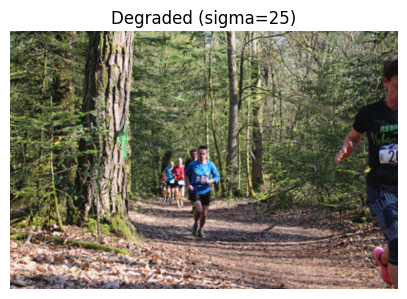

In [39]:
plt.figure(figsize=(5,5))
plt.title(f"Degraded (sigma={sigma})")
plt.imshow(degraded)
plt.axis("off")
plt.show()

In [40]:
img = degraded.astype(np.float32) / 255.0 # H,W,3
img = np.transpose(img, (2, 0, 1))        # 3,H,W
img = np.expand_dims(img, axis=0)         # 1,3,H,W

input_tensor = torch.from_numpy(img).float()

print("Tensor shape:", input_tensor.shape)

Tensor shape: torch.Size([1, 3, 1356, 2040])


In [41]:
with torch.no_grad():
    output = model(input_tensor)

print("Inference completed.")

Inference completed.


In [42]:
out = output.squeeze(0).cpu().numpy()
out = np.transpose(out, (1, 2, 0))
out = np.clip(out, 0, 1)
out = (out * 255).astype(np.uint8)

print("Output shape:", out.shape)

# Save this single test output
save_path = os.path.join(enhanced_dir, filename)
out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, out_bgr)

print("Saved test output to:", save_path)

Output shape: (1356, 2040, 3)
Saved test output to: ../data/enhanced_sigma_25/image_0.png


In [43]:
# Save denoised outputs for all images in the selected sigma folder
file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    degraded_path = os.path.join(degraded_dir, filename)

    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    if degraded is None:
        print(f"Skipping {filename}: could not read image")
        continue

    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

    img = degraded.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    input_tensor = torch.from_numpy(img).float()

    with torch.no_grad():
        output = model(input_tensor)

    out = output.squeeze(0).cpu().numpy()
    out = np.transpose(out, (1, 2, 0))
    out = np.clip(out, 0, 1)
    out = (out * 255).astype(np.uint8)

    save_path = os.path.join(enhanced_dir, filename)
    out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, out_bgr)

print(f"Done. Saved all denoised images to {enhanced_dir}")

Done. Saved all denoised images to ../data/enhanced_sigma_25


In [53]:
# Evaluate sigma=25 results and display comparison table
import os
import cv2
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

sigma = 25
clean_dir = "../data/clean"
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

results = []

file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    clean_path = os.path.join(clean_dir, filename)
    degraded_path = os.path.join(degraded_dir, filename)
    enhanced_path = os.path.join(enhanced_dir, filename)

    clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)
    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    enhanced = cv2.imread(enhanced_path, cv2.IMREAD_COLOR)

    if clean is None or degraded is None or enhanced is None:
        print(f"Skipping {filename}: missing file")
        continue

    clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)
    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    psnr_degraded = compare_psnr(clean, degraded, data_range=255)
    psnr_denoised = compare_psnr(clean, enhanced, data_range=255)

    ssim_degraded = compare_ssim(clean, degraded, channel_axis=2, data_range=255)
    ssim_denoised = compare_ssim(clean, enhanced, channel_axis=2, data_range=255)

    results.append({
        "image": filename,
        "PSNR_degraded": round(psnr_degraded, 2),
        "PSNR_denoised": round(psnr_denoised, 2),
        "SSIM_degraded": round(ssim_degraded, 4),
        "SSIM_denoised": round(ssim_denoised, 4),
    })

df_results = pd.DataFrame(results)

print("Per-image Results:")
print(df_results)

print("\nAverage Metrics for sigma=25:")
print(df_results[["PSNR_degraded", "PSNR_denoised", "SSIM_degraded", "SSIM_denoised"]].mean())

summary_25 = pd.DataFrame([{
    "sigma": 25,
    "avg_PSNR_degraded": round(df_results["PSNR_degraded"].mean(), 2),
    "avg_PSNR_denoised": round(df_results["PSNR_denoised"].mean(), 2),
    "avg_SSIM_degraded": round(df_results["SSIM_degraded"].mean(), 4),
    "avg_SSIM_denoised": round(df_results["SSIM_denoised"].mean(), 4),
}])

print("\nSummary Table:")
print(summary_25)

Per-image Results:
           image  PSNR_degraded  PSNR_denoised  SSIM_degraded  SSIM_denoised
0    image_0.png          17.05          17.05         0.2735         0.2738
1    image_1.png          17.72          17.72         0.2420         0.2428
2   image_10.png          18.08          18.09         0.2302         0.2309
3   image_11.png          20.60          20.62         0.1478         0.1487
4   image_12.png          19.07          19.07         0.1897         0.1900
5   image_13.png          19.22          19.22         0.2314         0.2318
6   image_14.png          19.23          19.21         0.2258         0.2259
7   image_15.png          19.29          19.28         0.1586         0.1587
8   image_16.png          19.47          19.46         0.1665         0.1666
9   image_17.png          18.42          18.43         0.1698         0.1707
10  image_18.png          20.31          20.31         0.1920         0.1926
11  image_19.png          19.63          19.64         0.

### Sigma = 15

In [45]:
sigma = 15
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

os.makedirs(enhanced_dir, exist_ok=True)

filename = sorted(os.listdir(degraded_dir))[0]

degraded_path = os.path.join(degraded_dir, filename)
clean_path = os.path.join("../data/clean", filename)

print("Testing:", filename)
print("Using degraded folder:", degraded_dir)
print("Enhanced output folder:", enhanced_dir)

Testing: image_0.png
Using degraded folder: ../data/degraded_sigma_15
Enhanced output folder: ../data/enhanced_sigma_15


In [46]:
degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)

degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)

print("Degraded shape:", degraded.shape)
print("Clean shape:", clean.shape)

Degraded shape: (1356, 2040, 3)
Clean shape: (1356, 2040, 3)


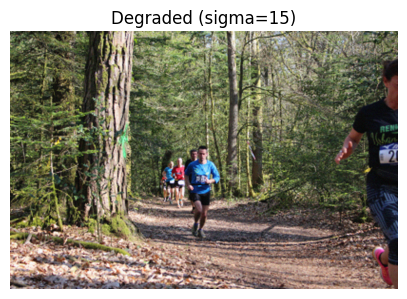

In [47]:
plt.figure(figsize=(5,5))
plt.title(f"Degraded (sigma={sigma})")
plt.imshow(degraded)
plt.axis("off")
plt.show()

In [48]:
img = degraded.astype(np.float32) / 255.0 # H,W,3
img = np.transpose(img, (2, 0, 1))        # 3,H,W
img = np.expand_dims(img, axis=0)         # 1,3,H,W

input_tensor = torch.from_numpy(img).float()

print("Tensor shape:", input_tensor.shape)

Tensor shape: torch.Size([1, 3, 1356, 2040])


In [49]:
with torch.no_grad():
    output = model(input_tensor)

print("Inference completed.")

Inference completed.


In [50]:
out = output.squeeze(0).cpu().numpy()
out = np.transpose(out, (1, 2, 0))
out = np.clip(out, 0, 1)
out = (out * 255).astype(np.uint8)

print("Output shape:", out.shape)

# Save this single test output
save_path = os.path.join(enhanced_dir, filename)
out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, out_bgr)

print("Saved test output to:", save_path)

Output shape: (1356, 2040, 3)
Saved test output to: ../data/enhanced_sigma_15/image_0.png


In [51]:
# Save denoised outputs for all images in the selected sigma folder
file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    degraded_path = os.path.join(degraded_dir, filename)

    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    if degraded is None:
        print(f"Skipping {filename}: could not read image")
        continue

    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)

    img = degraded.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    input_tensor = torch.from_numpy(img).float()

    with torch.no_grad():
        output = model(input_tensor)

    out = output.squeeze(0).cpu().numpy()
    out = np.transpose(out, (1, 2, 0))
    out = np.clip(out, 0, 1)
    out = (out * 255).astype(np.uint8)

    save_path = os.path.join(enhanced_dir, filename)
    out_bgr = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, out_bgr)

print(f"Done. Saved all denoised images to {enhanced_dir}")

Done. Saved all denoised images to ../data/enhanced_sigma_15


In [52]:
# Evaluate sigma=15 results and display comparison table
import os
import cv2
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

sigma = 15
clean_dir = "../data/clean"
degraded_dir = f"../data/degraded_sigma_{sigma}"
enhanced_dir = f"../data/enhanced_sigma_{sigma}"

results = []

file_list = sorted(os.listdir(degraded_dir))

for filename in file_list:
    clean_path = os.path.join(clean_dir, filename)
    degraded_path = os.path.join(degraded_dir, filename)
    enhanced_path = os.path.join(enhanced_dir, filename)

    clean = cv2.imread(clean_path, cv2.IMREAD_COLOR)
    degraded = cv2.imread(degraded_path, cv2.IMREAD_COLOR)
    enhanced = cv2.imread(enhanced_path, cv2.IMREAD_COLOR)

    if clean is None or degraded is None or enhanced is None:
        print(f"Skipping {filename}: missing file")
        continue

    clean = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)
    degraded = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    psnr_degraded = compare_psnr(clean, degraded, data_range=255)
    psnr_denoised = compare_psnr(clean, enhanced, data_range=255)

    ssim_degraded = compare_ssim(clean, degraded, channel_axis=2, data_range=255)
    ssim_denoised = compare_ssim(clean, enhanced, channel_axis=2, data_range=255)

    results.append({
        "image": filename,
        "PSNR_degraded": round(psnr_degraded, 2),
        "PSNR_denoised": round(psnr_denoised, 2),
        "SSIM_degraded": round(ssim_degraded, 4),
        "SSIM_denoised": round(ssim_denoised, 4),
    })

df_results = pd.DataFrame(results)

print("Per-image Results:")
print(df_results)

print("\nAverage Metrics for sigma=15:")
print(df_results[["PSNR_degraded", "PSNR_denoised", "SSIM_degraded", "SSIM_denoised"]].mean())

summary_15 = pd.DataFrame([{
    "sigma": 15,
    "avg_PSNR_degraded": round(df_results["PSNR_degraded"].mean(), 2),
    "avg_PSNR_denoised": round(df_results["PSNR_denoised"].mean(), 2),
    "avg_SSIM_degraded": round(df_results["SSIM_degraded"].mean(), 4),
    "avg_SSIM_denoised": round(df_results["SSIM_denoised"].mean(), 4),
}])

print("\nSummary Table:")
print(summary_15)

Per-image Results:
           image  PSNR_degraded  PSNR_denoised  SSIM_degraded  SSIM_denoised
0    image_0.png          18.55          18.55         0.3613         0.3617
1    image_1.png          19.42          19.42         0.3434         0.3454
2   image_10.png          19.99          19.98         0.3396         0.3406
3   image_11.png          24.50          24.49         0.2901         0.2909
4   image_12.png          21.66          21.64         0.3092         0.3093
5   image_13.png          21.96          21.95         0.3614         0.3615
6   image_14.png          22.05          22.02         0.3580         0.3580
7   image_15.png          22.36          22.34         0.2812         0.2812
8   image_16.png          22.40          22.37         0.2862         0.2863
9   image_17.png          20.41          20.42         0.2654         0.2684
10  image_18.png          24.06          24.04         0.3415         0.3424
11  image_19.png          22.44          22.43         0.